## Wearable Tech: Week 1 Assignment

## Step 1

In [1]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates
import datetime

# Read in the dataset

df = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 4 - Wearable Technologies and Sports Analytics/Week 1 Content/Week 1 Assignment/TexasTechVBall.csv")

## Step 2

In [3]:
# Make a copy of the dataset
df_vb=df

In [7]:
# Set up date and week columns
df_vb['DATE'] = pd.to_datetime(df_vb['DATE'])
df_vb['WEEK'] = (df_vb['DATE'].dt.isocalendar().week) - 33
df_vb['WEEK'] = df_vb['WEEK'].astype('object')

df_vb.head()

,EVENT NAME,EVENT TYPE,DATE,PLAYER NAME,POSITION,ENERGY,MAX ENERGY,SETS BY ENERGY,POWER,INTENSITY,...,JUMPS 15+,JUMPS 20+,HIGHEST JUMP (in),AVG HI JUMP (in),% MAX JUMP,MAX JUMP (in),HIGH LANDING %,ALERT LANDING %,ELEVATED LANDING %,WEEK
0,8/19/19,PRAC,2019-08-19,Erika,S,1595,2750,2.9,9.6,15.6,...,8,0,17.7,14.0,62,22.5,0,0,0,1
1,8-19-19#2,PRAC,2019-08-19,Erika,S,1020,2750,1.9,8.4,14.6,...,2,1,21.7,13.4,60,22.5,0,0,0,1
2,8/19/19,PRAC,2019-08-19,Adelaide,MB,1869,2500,4.7,9.4,16.8,...,126,8,22.2,18.8,75,25.0,3,2,5,1
3,8-19-19#2,PRAC,2019-08-19,Adelaide,MB,451,2500,1.1,8.4,10.0,...,41,2,20.4,17.9,72,25.0,4,0,4,1
4,8/19/19,PRAC,2019-08-19,Ingrid,OH,2747,3720,3.7,10.3,19.9,...,113,91,28.9,26.5,88,30.0,7,2,9,1


## Step 3

In [8]:
# Calculate the mean value for the total jumps for practice, scrimmage, and game days.
jumps_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['JUMPS']].mean()

print(jumps_per_position)

                          JUMPS
EVENT TYPE POSITION            
GAME       MB         77.652174
           OH         48.905660
           S          96.583333
PRAC       MB        132.010000
           OH         81.157407
           S         106.728814
SCRIMMAGE  MB        159.333333
           OH         90.000000
           S         138.750000


In [10]:
# Calculate the mean value for jumps over 15 for practice, scrimmage, and game days.
jumps15_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['JUMPS 15+']].mean()

print(jumps15_per_position)

                      JUMPS 15+
EVENT TYPE POSITION            
GAME       MB         64.391304
           OH         39.981132
           S          23.458333
PRAC       MB         97.520000
           OH         66.995370
           S          23.991525
SCRIMMAGE  MB        132.000000
           OH         80.428571
           S          37.250000


In [11]:
# Calculate the mean value for jumps over 20 inches for practice, scrimmage, and game days.
jumps20_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['JUMPS 20+']].mean()

print(jumps20_per_position)

                     JUMPS 20+
EVENT TYPE POSITION           
GAME       MB        24.434783
           OH        23.962264
           S          0.791667
PRAC       MB        22.450000
           OH        32.972222
           S          0.813559
SCRIMMAGE  MB        35.666667
           OH        53.142857
           S          3.000000


In [12]:
# Calculate the mean value for highest jumps for practice, scrimmage, and game days.
jumps_high_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['HIGHEST JUMP (in)']].mean()

print(jumps_high_per_position)

                     HIGHEST JUMP (in)
EVENT TYPE POSITION                   
GAME       MB                25.591304
           OH                26.794340
           S                 19.112500
PRAC       MB                24.363000
           OH                25.838605
           S                 19.203390
SCRIMMAGE  MB                24.600000
           OH                27.828571
           S                 20.225000


## Step 4

In [14]:
# Calculate the mean of elevated landing for players based on event type and position.
elev_landing_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['ELEVATED LANDING %']].mean()

print(elev_landing_per_position)

                     ELEVATED LANDING %
EVENT TYPE POSITION                    
GAME       MB                  7.739130
           OH                 12.867925
           S                   4.541667
PRAC       MB                  4.330000
           OH                  6.870370
           S                   1.245763
SCRIMMAGE  MB                  3.000000
           OH                 10.428571
           S                   3.750000


In [15]:
# Calculate the mean of high landing for players based on event type and position.
high_landing_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['HIGH LANDING %']].mean()

print(high_landing_per_position)

                     HIGH LANDING %
EVENT TYPE POSITION                
GAME       MB              5.608696
           OH             10.226415
           S               2.833333
PRAC       MB              3.420000
           OH              5.361111
           S               0.991525
SCRIMMAGE  MB              2.666667
           OH              6.285714
           S               3.500000


In [16]:
# Calculate the mean of alert landing for players based on event type and position.
alert_landing_per_position = df_vb.groupby(['EVENT TYPE','POSITION'])[['ALERT LANDING %']].mean()

print(alert_landing_per_position)

                     ALERT LANDING %
EVENT TYPE POSITION                 
GAME       MB               2.304348
           OH               2.622642
           S                1.791667
PRAC       MB               0.860000
           OH               1.504630
           S                0.271186
SCRIMMAGE  MB               0.333333
           OH               4.000000
           S                0.250000


## Step 5

Text(0, 0.5, 'Alert Landing %')

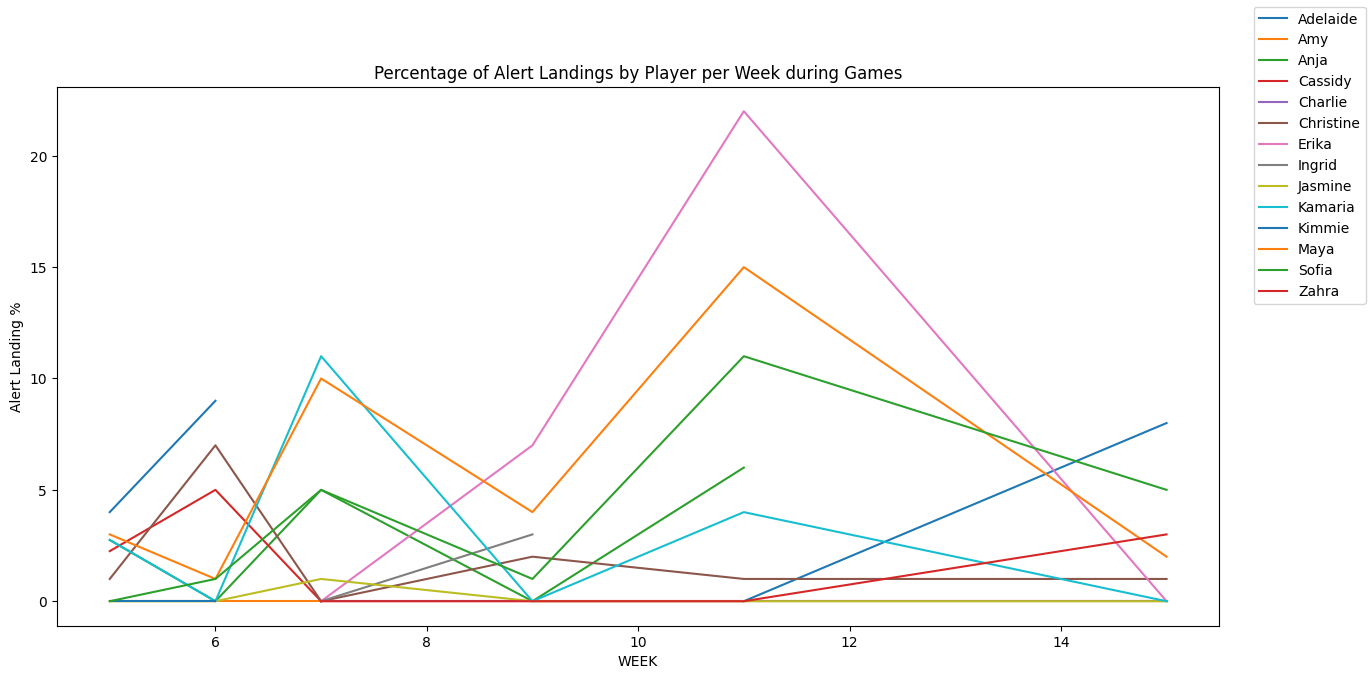

In [27]:
# Plot each player for their percentage of alert landings during games (only) according to the week of the season.
df_game = df_vb.loc[df_vb['EVENT TYPE'] == 'GAME']

# plot data
fig, ax = plt.subplots(figsize=(15,7))
# use unstack()
df_game.groupby(['WEEK', 'PLAYER NAME'])['ALERT LANDING %'].mean().unstack().plot(ax=ax, legend=False)

fig.legend(loc="upper right")
plt.title("Percentage of Alert Landings by Player per Week during Games")
plt.ylabel("Alert Landing %")

## Step 6

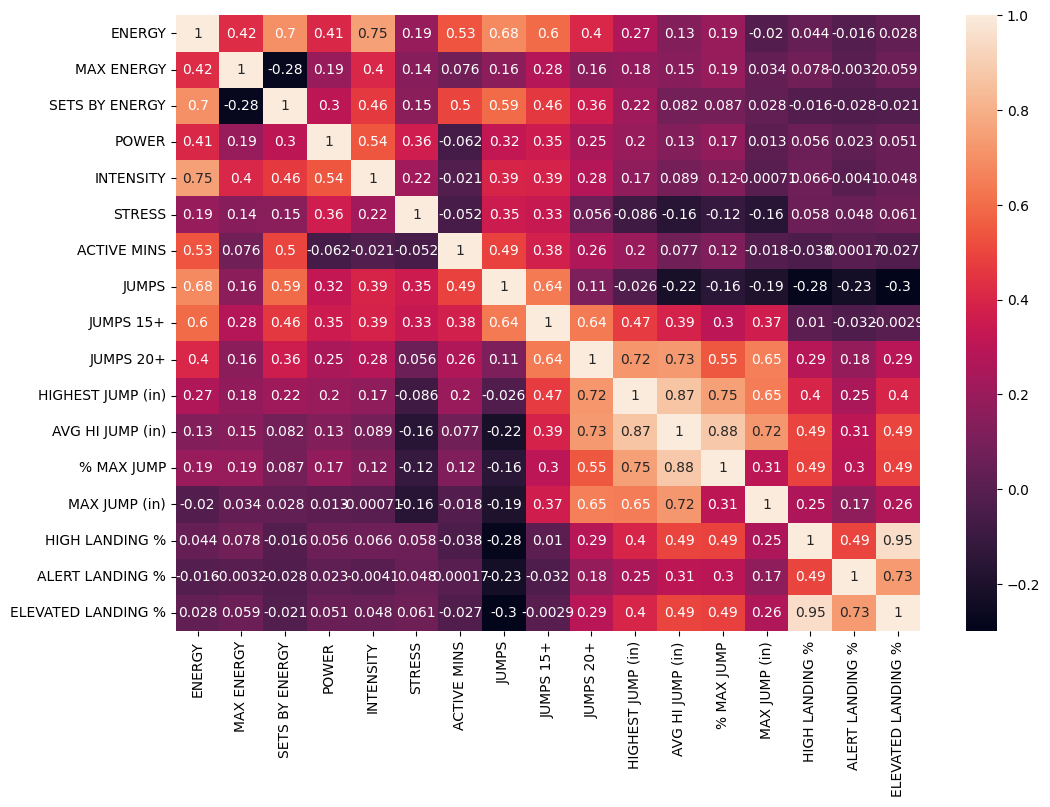

In [26]:
# Evaluate correlation matrix of the different vert measures to determine what factor(s) seem most highly correlated with the “elevated landing” measure.
#Determine which other measures (outside of the deceleration measures) are most highly correlated with the “elevated landing” measure.
corrMatrix = df_vb.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sn.heatmap(corrMatrix, annot=True)
plt.show()

From the correlation matrix we can see that the measure that is most highly correlated with elevated landing % is high landing % with a correlation coefficient of 0.95 which indicates a highly positive correlation.

The measure that is most positively correlated with elevated landing % outside of the deceleration measures is a tie between AVG Hi Jump (in) and % Max Jump both with a correlation coefficient of 0.49 indicating a strong positive correlation.